# 05 — Comparativo Final: Três Paradigmas, Um Dataset

## Bloco 1 — Contexto e pergunta

Este notebook encerra a Aula 01 consolidando, em um único lugar, os três paradigmas de aprendizado de máquina aplicados ao mesmo dataset MovieLens.

Cada notebook anterior respondeu a uma pergunta diferente com o mesmo conjunto de dados:

| Notebook | Pergunta | Paradigma |
|---|---|---|
| `02` | O usuário vai gostar deste filme? | Supervisionado |
| `03` | Que tipos de usuários existem? | Não supervisionado |
| `04` | Qual filme recomendar agora? | Aprendizado por Reforço |

O objetivo aqui não é repetir as análises, mas **colocar os três outputs lado a lado** e tornar visível o que os separa: não os dados — que são os mesmos — mas a **pergunta formulada ao sistema**, que determina o paradigma, o sinal de aprendizado e o tipo de resposta possível.

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 01 — Paradigmas de ML com MovieLens |
| **Notebook** | 05 — Comparativo Final |
| **Seções** | 1.1–1.4 (síntese dos três paradigmas) |
| **Tempo de leitura** | 12 min |
| **Tempo de execução (padrão)** | 8 min |

### Pré-requisitos

- **Notebooks anteriores:** `02`, `03` e `04` — todos os três paradigmas devem ter sido executados antes.
- **Conceitos:** rótulo, cluster, recompensa, política, MDP.

### Competências para o Desafio Final

- Escolher o paradigma adequado para cada componente do Desafio Final.
- Reproduzir os três outputs lado a lado a partir do mesmo dataset MovieLens.
- Explicar como supervisionado, não supervisionado e RL coexistem em sistemas de recomendação industriais.

### Recapitulando

Nos notebooks `02`, `03` e `04` aplicamos os três paradigmas ao MovieLens: regressão logística para prever preferência, K-Means para segmentar usuários e um bandit ε-greedy para recomendar por interação. Este notebook consolida os três outputs lado a lado — o que os separa não são os dados, mas a **pergunta formulada ao sistema**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0


torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1


scikit-learn         1.8.0


## Bloco 2 — Mini teoria

### Quadro comparativo dos três paradigmas

| Paradigma | Pergunta | Dado | Sinal de aprendizado | Saída | Limitação principal |
|---|---|---|---|---|---|
| Supervisionado | O usuário vai gostar deste filme? | Pares (usuário, filme) com nota conhecida | Rótulo — erro entre previsão e resposta correta | Probabilidade de gostar; classificação | Depende de rótulos históricos; não modela decisão sequencial |
| Não supervisionado | Que perfis de usuários ou filmes existem? | Observações sem alvo explícito | Estrutura interna — similaridade entre pontos | Clusters, segmentos, representações | Não gera decisão direta; perfis estáticos não capturam deriva de preferência |
| Aprendizado por Reforço | Qual filme recomendar agora para maximizar engajamento futuro? | Interações sequenciais com feedback | Recompensa — sinal recebido após cada ação | Política de decisão (formalizada como MDP) | Requer exploração; mais complexo de treinar e avaliar |

### Como os três paradigmas coexistem em sistemas reais

Em sistemas de recomendação industriais, os três paradigmas operam em camadas complementares:

- O **não supervisionado** é executado offline para segmentar usuários e construir representações do catálogo. Esses perfis alimentam as etapas seguintes.
- O **supervisionado** estima, para cada candidato, a probabilidade de satisfação — e ranqueia os itens antes de exibi-los.
- O **Aprendizado por Reforço** atua na camada de decisão final: dado o ranqueamento, qual item mostrar agora, considerando o efeito de longo prazo sobre o engajamento do usuário?

Nenhum dos três paradigmas resolve o problema completo de recomendação isoladamente. A combinação entre eles — segmentação, previsão e decisão sequencial — é o que sustenta sistemas como os da Netflix, Spotify e YouTube.

## Bloco 3 — Código didático mínimo

Este notebook é autocontido: recarrega os dados e reproduz os três outputs de forma independente.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RATINGS_PATH = 'data/movielens/ratings.csv'
MOVIES_PATH  = 'data/movielens/movies.csv'
SEED = 42
rng  = np.random.default_rng(SEED)

try:
    ratings = pd.read_csv(RATINGS_PATH)
    movies  = pd.read_csv(MOVIES_PATH)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f'{e}\nExecute o notebook 01_contexto_movielens.ipynb para preparar os dados.'
    )

ratings['gostou'] = (ratings['rating'] >= 4).astype(int)
print(f'Dados carregados: {len(ratings):,} avaliações, {ratings["userId"].nunique()} usuários, '
      f'{ratings["movieId"].nunique()} filmes.')

Dados carregados: 100,836 avaliações, 610 usuários, 9724 filmes.


In [3]:
# ── Output 1: Supervisionado ─────────────────────────────────────────────────
print('── Output 1 — Supervisionado: "O usuário vai gostar deste filme?" ──\n')

sample = ratings.sample(n=min(30_000, len(ratings)), random_state=SEED).copy()

user_stats = sample.groupby('userId').agg(
    media_usuario=('rating', 'mean'),
    qtd_avaliacoes_usuario=('rating', 'count'),
).reset_index()
film_stats = sample.groupby('movieId').agg(
    media_filme=('rating', 'mean'),
).reset_index()

df_sup = (
    sample[['userId', 'movieId', 'gostou']]
    .merge(user_stats, on='userId')
    .merge(film_stats, on='movieId')
)

FEATURES = ['media_usuario', 'media_filme', 'qtd_avaliacoes_usuario']
X = df_sup[FEATURES].values
y = df_sup['gostou'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
scaler = StandardScaler()
modelo = LogisticRegression(max_iter=300, random_state=SEED)
modelo.fit(scaler.fit_transform(X_train), y_train)

amostra_sup = df_sup[FEATURES + ['gostou']].sample(5, random_state=SEED).copy()
amostra_sup['prob_gostou'] = modelo.predict_proba(
    scaler.transform(amostra_sup[FEATURES].values)
)[:, 1].round(3)
amostra_sup['pred_gostou'] = modelo.predict(scaler.transform(amostra_sup[FEATURES].values))

print(f'Acurácia no conjunto de teste: {modelo.score(scaler.transform(X_test), y_test):.3f}\n')
print('5 exemplos — rótulo real vs. previsão:')
display(amostra_sup.reset_index(drop=True))

── Output 1 — Supervisionado: "O usuário vai gostar deste filme?" ──

Acurácia no conjunto de teste: 0.758

5 exemplos — rótulo real vs. previsão:


,media_usuario,media_filme,qtd_avaliacoes_usuario,gostou,prob_gostou,pred_gostou
0,3.134615,3.184211,26,0,0.158,0
1,3.083333,3.900000,198,1,0.480,0
2,3.812057,4.750000,141,1,0.962,1
3,3.255319,3.548387,141,1,0.357,0
4,3.934426,4.142857,61,1,0.883,1


── Output 2 — Não supervisionado: "Que tipos de usuários existem?" ──



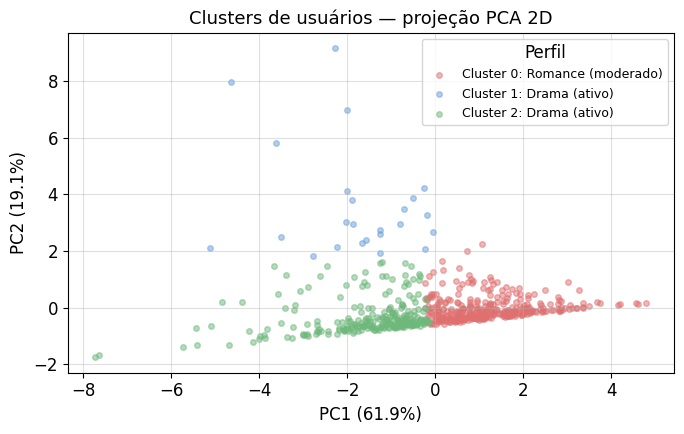

In [4]:
# ── Output 2: Não supervisionado ─────────────────────────────────────────────
print('── Output 2 — Não supervisionado: "Que tipos de usuários existem?" ──\n')

GENEROS = ['Action', 'Comedy', 'Drama', 'Romance']
merged  = ratings.merge(movies[['movieId', 'genres']], on='movieId', how='left')

user_ns = ratings.groupby('userId').agg(qtd_avaliacoes=('rating', 'count')).reset_index()
media_g = ratings.groupby('userId')['rating'].mean().rename('media_global')
user_ns = user_ns.merge(media_g.reset_index(), on='userId')

for genero in GENEROS:
    col  = f'nota_{genero.lower()}'
    mask = merged['genres'].fillna('').str.contains(genero, regex=False)
    serie = merged[mask].groupby('userId')['rating'].mean().rename(col)
    user_ns = user_ns.merge(serie.reset_index(), on='userId', how='left')
    user_ns[col] = user_ns[col].fillna(user_ns['media_global'])

user_ns = user_ns.drop(columns=['media_global'])
FEAT_NS = ['qtd_avaliacoes'] + [f'nota_{g.lower()}' for g in GENEROS]

sc_ns  = StandardScaler()
X_ns   = sc_ns.fit_transform(user_ns[FEAT_NS].values)
km     = KMeans(n_clusters=3, random_state=SEED, n_init=10)
user_ns['cluster'] = km.fit_predict(X_ns)

medias_c    = user_ns.groupby('cluster')[FEAT_NS].mean()
media_geral = user_ns[[f'nota_{g.lower()}' for g in GENEROS]].mean()
CORES       = ['#e07070', '#6a9fd8', '#6db87a']

rotulos = {}
for c in sorted(user_ns['cluster'].unique()):
    genre_cols = [f'nota_{g.lower()}' for g in GENEROS]
    dom    = (medias_c.loc[c, genre_cols] - media_geral).idxmax().replace('nota_', '').capitalize()
    p33, p66 = user_ns['qtd_avaliacoes'].quantile([0.33, 0.66])
    nivel  = 'ativo' if medias_c.loc[c, 'qtd_avaliacoes'] >= p66 else \
             ('casual' if medias_c.loc[c, 'qtd_avaliacoes'] <= p33 else 'moderado')
    rotulos[c] = f'Cluster {c}: {dom} ({nivel})'

pca = PCA(n_components=2, random_state=SEED)
Z   = pca.fit_transform(X_ns)
var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
for c in sorted(user_ns['cluster'].unique()):
    mask = user_ns['cluster'].values == c
    ax.scatter(Z[mask, 0], Z[mask, 1],
               c=CORES[c % len(CORES)], label=rotulos[c], alpha=0.5, s=16)
ax.set_xlabel(f'PC1 ({var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]:.1f}%)')
ax.set_title('Clusters de usuários — projeção PCA 2D')
ax.legend(title='Perfil', fontsize=9)
plt.tight_layout()
plt.show()

── Output 3 — RL: "Qual filme recomendar agora?" ──



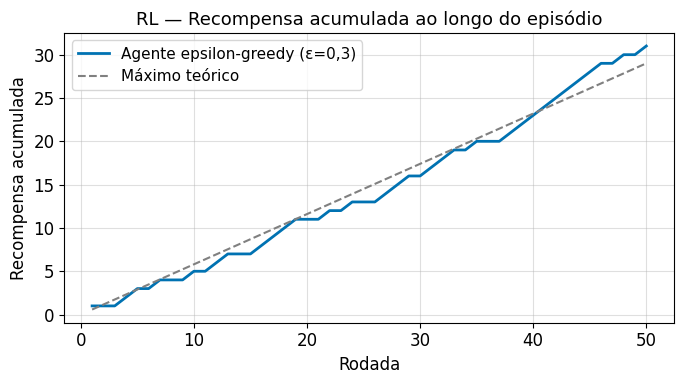

Q estimado vs. probabilidade histórica real:


,movieId,p_recompensa,q_estimado,n_escolhas
0,333,0.580000,0.658,38
1,1663,0.500000,0.600,5
2,163,0.454545,0.429,7


In [5]:
# ── Output 3: Aprendizado por Reforço ────────────────────────────────────────
print('── Output 3 — RL: "Qual filme recomendar agora?" ──\n')

ratings['recompensa'] = ratings['gostou'].copy()

candidatos = (
    ratings.groupby('movieId')
    .agg(p_recompensa=('recompensa', 'mean'), n=('recompensa', 'count'))
    .query('n >= 30')
    .sample(3, random_state=SEED)
    .sort_values('p_recompensa', ascending=False)
    .reset_index()
)
TRUE_P    = candidatos['p_recompensa'].to_numpy()
N_ACOES   = len(candidatos)
EPSILON   = 0.3
N_RODADAS = 50

q = np.zeros(N_ACOES)
n = np.zeros(N_ACOES)
recompensa_acumulada = 0
log_rl = []

for rodada in range(1, N_RODADAS + 1):
    acao = int(rng.integers(N_ACOES)) if rng.random() < EPSILON else int(np.argmax(q))
    r    = int(rng.random() < TRUE_P[acao])
    recompensa_acumulada += r
    n[acao] += 1
    q[acao] += (r - q[acao]) / n[acao]
    log_rl.append({'rodada': rodada, 'recompensa_acumulada': recompensa_acumulada})

df_rl   = pd.DataFrame(log_rl)
otimo   = np.arange(1, N_RODADAS + 1) * TRUE_P.max()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_rl['rodada'], df_rl['recompensa_acumulada'],
        linewidth=2, label='Agente epsilon-greedy (ε=0,3)')
ax.plot(df_rl['rodada'], otimo,
        linestyle='--', color='gray', label='Máximo teórico')
ax.set_xlabel('Rodada')
ax.set_ylabel('Recompensa acumulada')
ax.set_title('RL — Recompensa acumulada ao longo do episódio')
ax.legend()
plt.tight_layout()
plt.show()

resultado = candidatos[['movieId', 'p_recompensa']].copy()
resultado['q_estimado'] = q.round(3)
resultado['n_escolhas'] = n.astype(int)
print('Q estimado vs. probabilidade histórica real:')
display(resultado)

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| paradigm | paradigma | Abordagem metodológica que define o tipo de aprendizado e o sinal de treinamento. |
| learning signal | sinal de aprendizado | Informação que guia o ajuste do modelo: rótulo, similaridade interna ou recompensa. |
| sequential decision | decisão sequencial | Sequência de escolhas ao longo do tempo onde cada decisão afeta o estado futuro. |
| recommendation system | sistema de recomendação | Sistema que sugere itens a usuários com base em histórico, perfil e feedback. |
| policy | política | π — regra que mapeia estados a ações; o produto final do aprendizado por reforço. |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Bloco 4 — Interpretação pedagógica

### Output 1 — Supervisionado

A tabela mostra pares (usuário, filme) com o rótulo real (`gostou`) e a probabilidade estimada pelo modelo (`prob_gostou`). O que o modelo fez: olhou para o histórico de avaliações e aprendeu a prever se o padrão de notas do usuário e do filme, tomados em conjunto, indicam satisfação.

A coluna `prob_gostou` é o produto direto do treinamento. O modelo não escolheu nenhum filme — apenas estimou uma probabilidade para pares já formados. A decisão de *qual* filme mostrar ainda não foi respondida.

### Output 2 — Não supervisionado

O gráfico PCA revela que os usuários formam grupos com características distintas de consumo. Cada cluster corresponde a um perfil latente — definido pelas médias de nota por gênero e pelo volume de avaliações — sem que nenhum rótulo fosse necessário para encontrá-lo.

O que o algoritmo fez: organizou os usuários no espaço de features de forma que usuários similares ficassem próximos. O gráfico é uma projeção 2D desse agrupamento — a separação visual entre os clusters indica que os perfis são genuinamente distintos.

A pergunta "que tipos de usuários existem?" foi respondida. A pergunta "qual filme recomendar para este usuário agora?" ainda não.

### Output 3 — Aprendizado por Reforço

O gráfico de recompensa acumulada mostra o agente aprendendo ao longo de 50 rodadas. A curva sobe porque o agente, por tentativa e erro, passa a identificar e explorar a ação com maior probabilidade histórica de satisfação.

A linha tracejada é o máximo teórico — o que um agente onisciente que sempre escolhe a ação ótima obteria. A diferença entre as curvas é o custo da exploração: rodadas investidas em descobrir o valor das ações ainda desconhecidas.

O que esse output mostra que os anteriores não mostram: o agente **age** e **aprende com as consequências** ao longo do tempo.

---

### Mensagem central da aula

> **O dataset é o mesmo. O que muda é a pergunta formulada ao sistema — e essa pergunta determina o paradigma, o sinal de aprendizado e o tipo de resposta possível.**

Formular corretamente a pergunta é o primeiro passo em qualquer projeto de ML. Antes de escolher um algoritmo, é preciso definir: existe rótulo? O objetivo é prever, descobrir estrutura ou tomar decisões sequenciais? A resposta a essas perguntas determina o paradigma adequado.

## Autoavaliação

<details>
<summary>Pergunta 1: Por que os três paradigmas produzem saídas diferentes mesmo usando o mesmo dataset MovieLens?</summary>

**Resposta:** Porque o paradigma é determinado pela *pergunta*, não pelos dados. O supervisionado usa o rótulo `gostou` para aprender a prever; o não supervisionado ignora o rótulo e organiza usuários por similaridade de preferências; o RL define uma função de recompensa e aprende uma política de ação. O mesmo par (usuário, filme) é um exemplo de treino no supervisionado, um ponto em um espaço de features no não supervisionado, e uma interação passada no RL.

**Por quê:** A escolha do paradigma precede a escolha do algoritmo. Antes de selecionar um modelo, é necessário definir: existe rótulo? O objetivo é prever, descobrir estrutura ou agir?

</details>

<details>
<summary>Pergunta 2: Em que situação o aprendizado supervisionado seria insuficiente para um sistema de recomendação?</summary>

**Resposta:** Quando o objetivo é maximizar o engajamento *ao longo do tempo*, não prever uma nota pontual. O supervisionado estima P(gostou | usuário, filme) para pares individuais — mas não modela a sequência de recomendações: recomendar A hoje pode influenciar o que o usuário quer amanhã. Além disso, sem rótulos históricos (usuários novos, filmes sem avaliação), o supervisionado não tem sinal de aprendizado.

**Por quê:** Decisão sequencial com consequências futuras é o domínio do RL. O supervisionado é estático — aprende com o passado mas não planeja o futuro.

</details>

<details>
<summary>Pergunta 3: Como a segmentação de usuários (não supervisionado) pode ser combinada com RL para melhorar o sistema de recomendação?</summary>

**Resposta:** Os clusters de usuários podem definir *estados* para o agente de RL. Em vez de um estado contínuo de alta dimensão (histórico completo de avaliações), o agente observa a qual cluster o usuário pertence — um estado discreto e tratável. O não supervisionado reduz o espaço do problema; o RL aprende a agir dentro desse espaço comprimido.

**Por quê:** Combinar paradigmas é a prática em sistemas reais: segmentação offline alimenta políticas online. Nenhum paradigma resolve sozinho o problema completo de recomendação sequencial.

</details>

## Conexão com o problema de recomendação MovieLens

Os três outputs gerados neste notebook são peças complementares de um sistema de recomendação real:

| Output | Componente do sistema | Limitação isolada |
|---|---|---|
| **Supervisionado** — P(gostou) | *Ranqueador*: estima a probabilidade de satisfação para cada candidato | Não decide qual item mostrar; não aprende com sequências |
| **Não supervisionado** — clusters | *Segmentador*: agrupa usuários por perfil de consumo | Não gera decisão direta; perfis estáticos não capturam mudanças de preferência |
| **RL** — bandit ε-greedy | *Decisor*: escolhe qual filme mostrar e aprende com o feedback | Sem estado variável; não considera efeitos de longo prazo |

Em sistemas industriais (Netflix, Spotify, YouTube), os três componentes operam em camadas:

1. O **não supervisionado** segmenta usuários offline e alimenta representações de perfil.
2. O **supervisionado** ranqueia candidatos por probabilidade de satisfação para cada segmento.
3. O **RL** toma a decisão final sobre qual item exibir, considerando o engajamento acumulado ao longo do tempo.

> **Mensagem central:** o MovieLens é um único dataset — mas a pergunta formulada ao sistema determina qual paradigma, qual sinal de aprendizado e qual tipo de resposta são adequados.

## Mapeamento para o Desafio Final

| Paradigma | Competência construída | Quando usar no Desafio Final |
|---|---|---|
| **Supervisionado** | Prever P(gostou) com regressão logística; interpretar probabilidade e histograma | Componente de *ranqueamento*: filtrar e ordenar candidatos antes da decisão final |
| **Não supervisionado** | Segmentar usuários em clusters por padrão de consumo; interpretar PCA | Componente de *estado*: representar o perfil do usuário de forma compacta para o agente de RL |
| **RL — Bandit** | Implementar política ε-greedy; calcular Q(a) e regret; formular o MDP | Componente de *decisão*: escolher qual item recomendar e aprender com o feedback sequencial |

**Arquitetura completa para o Desafio Final:**

1. Usar **K-Means** para segmentar usuários → define os *estados* do MDP.
2. Usar **regressão logística** para ranquear candidatos por P(gostou) → pré-filtra o espaço de ações.
3. Usar **bandit ε-greedy** (ou Q-Learning completo) para escolher o item final → aprende com feedback sequencial.

Esta arquitetura em camadas é o padrão de sistemas de recomendação industriais — e a progressão das Aulas 01 a 04 cobre cada componente em crescente profundidade.

## Bloco 5 — Limites e transição

### O que a Aula 01 estabeleceu

Esta aula cobriu o nível conceitual e introdutório:

- Definiu os três paradigmas de ML e seus sinais de aprendizado distintos.
- Demonstrou, no mesmo contexto MovieLens, como cada paradigma responde a uma pergunta diferente.
- Formalizou o Aprendizado por Reforço como um **Processo de Decisão de Markov** (MDP) com cinco componentes: estados, ações, transições, recompensas e fator de desconto.
- Implementou um bandit epsilon-greedy como primeira aproximação ao problema de decisão sequencial.

### O que a Aula 02 aprofundará

O bandit deste notebook não tem estados que mudam — cada rodada é independente. O MDP completo exige um mecanismo que propague o valor de decisões futuras de volta para o presente, permitindo que o agente planeje.

A Aula 02 introduz os primeiros algoritmos que resolvem MDPs completos de forma sistemática:

| Algoritmo | Mecanismo central |
|---|---|
| **Q-Learning** | Atualização iterativa de Q(s,a) com amostras de experiência; converge para a política ótima em MDPs discretos |
| **SARSA** | Variante on-policy: atualiza Q com a ação efetivamente tomada pela política atual |
| **DQN** | Aproxima Q(s,a) com rede neural profunda; estende Q-Learning a espaços de estado contínuos e de alta dimensão |

Esses algoritmos compartilham o vocabulário do MDP apresentado nesta aula — estados, ações, recompensas, política e função de valor — e serão analisados sob o mesmo contexto de recomendação.

## Leituras e referências

- Sutton, R. S.; Barto, A. G. *Reinforcement Learning: An Introduction*. 2. ed. MIT Press, 2018. Disponível em: http://incompleteideas.net/book/the-book-2nd.html (acesso em 2026-03-07).
- Hastie, T.; Tibshirani, R.; Friedman, J. *The Elements of Statistical Learning*. Springer, 2009. Cap. 4 (Regressão Logística) e Cap. 14 (Métodos não supervisionados).
- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability*, 1, 281–297.
- Pedregosa, F. et al. Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830, 2011. Disponível em: https://scikit-learn.org (acesso em 2026-03-07).
- Harper, F. M.; Konstan, J. A. (2015). The MovieLens Datasets: History and Context. *ACM Transactions on Interactive Intelligent Systems*, 5(4).
- MovieLens (GroupLens): https://grouplens.org/datasets/movielens/ (acesso em 2026-03-07).
- Roteiro da Aula 01, Vídeo 5: `roteiros/Aula 01 - Roteiro video aula.md`.